# Case Study 1

#### Model selection for Clustering

Clustering is unsupervised learning: the resulting clusters are completely derived from data distributed in given a feature set with no class available

Compared to supervised learning counterparts, it is …
* hard to define model performance (cluster quality)
* sensitive to different clustering algorithms and different feature spaces.



#### Task
Your task is to try different clustering algorithms and also a range of the potential parameter(s) which affect the number of clusters including ..

* K-means
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
* Gaussian Mixture Model, 
https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture
* Hierarchical Clustering, 
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering
* Louvain Clustering, 
https://scikit-network.readthedocs.io/en/latest/reference/clustering.html#module-sknetwork.clustering

on 5K colorectal patches represented by 4 different representation PathologyGAN, ResNet50, InceptionV3 and VGG16


#### Data and its preprocessing 
5,000 non-overlapping image patches from hematoxylin & eosin (H&E) stained histological images of human colorectal cancer (CRC) and normal tissue.
* 4 feature sets, PathologyGAN, ResNet50, InceptionV3 and VGG16, are extracted to represent those 5,000 images different dimensional feature spaces.
* PCA and UMAP were employed to reduce each feature sapce into 100-dimensional vectors

* 9 tissue types are also available which include Adipose (ADI), background (BACK), debris (DEB), lymphocytes (LYM), mucus (MUC), smooth muscle (MUS), normal colon mucosa (NORM), cancer-associated stroma (STR), colorectal adenocarcinoma epithelium (TUM)


#### Performance Measurement
To assess quality of clustering solutions, several approaches are expected to be done and interpreted which include...
* Silhouette Score for goodness of fit test
* Vmeasure Score for homogeneity and completeness test (tissue type available as ground truth)
* Clusters visualisations

For more information, please have a check...
https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation


#### Report
Report on your preprocessing pipeline, theory and intuition behinds each algorithm and representation, parameter searching and performance evaluation frameworks. If there is any addiotional process, give evidences/justifications on how it helps.

#### Required Packages

In [1]:
# !pip install h5py==2.10.0
# !pip install numpy
# !pip install pandas
# !pip install sklearn
# !pip install scikit-network
# !pip install pickle-mixin==1.0.2
# !pip install matplotlib
# !pip install plotly

### Prepare Tissue Representations

In [2]:
import h5py
import numpy as np
import pickle

In [3]:
pge_path = 'colon_nct_feature\\pge_dim_reduced_feature.h5'
resnet50_path = 'colon_nct_feature\\resnet50_dim_reduced_feature.h5'
#inceptionv3_path = 'colon_nct_feature\\inceptionv3_dim_reduced_feature.h5'
#vgg16_path = 'colon_nct_feature\\vgg16_dim_reduced_feature.h5'

pge_content = h5py.File(pge_path, mode='r')
resnet50_content = h5py.File(resnet50_path, mode='r')
#inceptionv3_content = h5py.File(inceptionv3_path, mode='r')
#vgg16_content = h5py.File(vgg16_path, mode='r')


In [4]:
pge_content

<HDF5 file "pge_dim_reduced_feature.h5" (mode r)>

In [5]:
resnet50_content

<HDF5 file "resnet50_dim_reduced_feature.h5" (mode r)>

In [6]:
#PCA feature from 4 feature sets: pge_latent, resnet50_latent, inceptionv3_latent, vgg16_latent
pge_pca_feature  = pge_content['pca_feature'][...]
resnet50_pca_feature  = resnet50_content['pca_feature'][...]
#inceptionv3_pca_feature = inceptionv3_content['pca_feature'][...]
#vgg16_pca_feature  = vgg16_content['pca_feature'][...]

In [7]:
pge_pca_feature

array([[-3.0926747e+00,  1.1020627e+00, -7.4318394e-02, ...,
         1.9986156e-02,  8.4324218e-02, -4.1100543e-02],
       [-3.4460149e+00,  1.7983061e+00, -9.0485513e-01, ...,
        -1.0090529e-01, -1.6424106e-02, -2.8848931e-02],
       [-3.7669258e+00,  2.7572019e+00, -2.0083770e-01, ...,
         1.8441271e-02,  8.5952744e-02, -3.0304456e-02],
       ...,
       [ 4.2488699e+00,  5.1506352e+00, -2.7983534e-01, ...,
        -6.5788500e-02,  8.6044157e-03, -6.1421674e-02],
       [ 1.6042002e+00, -1.6147038e+00,  1.5758495e+00, ...,
        -6.0373917e-02, -5.2043803e-02, -8.2069546e-02],
       [ 2.6385751e+00, -9.8035985e-01, -1.0775021e+00, ...,
        -8.8430906e-04, -3.1492118e-02, -4.3888927e-02]],
      shape=(5000, 100), dtype=float32)

In [8]:
resnet50_pca_feature

array([[-1.35499735e+01, -6.84221268e+00,  2.09675026e+01, ...,
        -6.57598078e-01, -1.44355178e-01,  6.91047788e-01],
       [-1.34704723e+01, -9.11547244e-03,  1.43632565e+01, ...,
         5.36932230e-01, -8.70337784e-01,  2.89299667e-01],
       [-1.29791269e+01,  2.69815779e+00,  1.65139313e+01, ...,
        -8.91254306e-01, -6.96573973e-01,  6.78322077e-01],
       ...,
       [ 9.59372997e-01, -8.24108958e-01, -2.09711480e+00, ...,
         6.18234873e-02, -6.23967350e-02, -2.07623768e+00],
       [ 3.37744689e+00, -2.12503028e+00,  4.33473396e+00, ...,
        -9.82406437e-01, -4.78535652e-01,  6.66808486e-02],
       [ 1.32709312e+01, -4.27860737e+00, -1.22849631e+00, ...,
        -1.02852285e-02,  8.68526220e-01,  5.05480766e-01]],
      shape=(5000, 100), dtype=float32)

In [9]:
#UMAP feature from 4 feature sets: pge_latent, resnet50_latent, inceptionv3_latent, vgg16_latent
pge_umap_feature  = pge_content['umap_feature'][...]
resnet50_umap_feature = resnet50_content['umap_feature'][...]
#inceptionv3_umap_feature  = inceptionv3_content['umap_feature'][...]
#vgg16_umap_feature  = vgg16_content['umap_feature'][...]

In [10]:
#tissue type as available ground-truth: labels
filename  = np.squeeze(pge_content['file_name'])
filename = np.array([str(x) for x in filename])
labels = np.array([x.split('/')[2] for x in filename])
labels

array(['ADI', 'ADI', 'ADI', ..., 'TUM', 'TUM', 'TUM'],
      shape=(5000,), dtype='<U4')

# Example

In [11]:
import random

PATHALOGYGAN PCA FEATURE 

In [12]:
random.seed(0)
selected_index = random.sample(list(np.arange(len(pge_pca_feature))), 200)

In [13]:
pge_test_data = pge_pca_feature[selected_index]
pge_test_label = labels[selected_index]

### Exploratory Analysis

In [14]:
import plotly.graph_objects as go
import pandas as pd

In [15]:
traces = []
for name in np.unique(labels):
    trace = go.Scatter3d(
        x=pge_test_data[pge_test_label==name,0],
        y=pge_test_data[pge_test_label==name,1],
        z=pge_test_data[pge_test_label==name,2],
        mode='markers',
        name=name,
        marker=go.scatter3d.Marker(
            size=4,
            opacity=0.8
        )
    )
    traces.append(trace)


data = go.Data(traces)
layout = go.Layout(
            showlegend=True,
    scene=go.Scene(
                xaxis=go.layout.scene.XAxis(title='PC1'),
                yaxis=go.layout.scene.YAxis(title='PC2'),
                zaxis=go.layout.scene.ZAxis(title='PC3')
                )
)
fig = go.Figure(data=data, layout=layout)
fig.update_layout(
    title="First 3 pricipal components of PathologyGAN's PCA feature",
    legend_title="Legend Title",
)

fig.show()


c:\Users\Vaishnavi Kshirsagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotly\graph_objs\_deprecations.py:31: DeprecationWarning: plotly.graph_objs.Data is deprecated.
Please replace it with a list or tuple of instances of the following types
  - plotly.graph_objs.Scatter
  - plotly.graph_objs.Bar
  - plotly.graph_objs.Area
  - plotly.graph_objs.Histogram
  - etc.

  warnings.warn(
c:\Users\Vaishnavi Kshirsagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotly\graph_objs\_deprecations.py:489: DeprecationWarning: plotly.graph_objs.Scene is deprecated.
Please replace it with one of the following more specific types
  - plotly.graph_objs.layout.Scene

  warnings.warn(


PATHALOGYGAN UMAP FEATURE REPRESENTATION 

In [16]:
random.seed(0)
selected_index = random.sample(list(np.arange(len(pge_umap_feature))), 200)

In [17]:
pge_test_umap_data = pge_umap_feature[selected_index]
pge_test_umap_label = labels[selected_index]

In [18]:
pge_test_umap_label

array(['MUS', 'NORM', 'ADI', 'LYM', 'STR', 'STR', 'MUS', 'MUC', 'STR',
       'MUS', 'TUM', 'LYM', 'STR', 'DEB', 'MUC', 'DEB', 'BACK', 'LYM',
       'TUM', 'TUM', 'DEB', 'MUC', 'BACK', 'BACK', 'MUS', 'STR', 'TUM',
       'BACK', 'MUS', 'NORM', 'MUC', 'LYM', 'TUM', 'STR', 'NORM', 'TUM',
       'LYM', 'ADI', 'TUM', 'ADI', 'BACK', 'MUS', 'ADI', 'STR', 'MUS',
       'LYM', 'MUS', 'ADI', 'DEB', 'TUM', 'LYM', 'LYM', 'DEB', 'TUM',
       'NORM', 'BACK', 'BACK', 'MUC', 'STR', 'STR', 'BACK', 'MUC', 'TUM',
       'MUC', 'BACK', 'TUM', 'MUS', 'TUM', 'LYM', 'TUM', 'TUM', 'TUM',
       'MUC', 'NORM', 'BACK', 'TUM', 'MUS', 'MUC', 'TUM', 'LYM', 'MUC',
       'DEB', 'DEB', 'DEB', 'ADI', 'LYM', 'STR', 'BACK', 'BACK', 'BACK',
       'DEB', 'ADI', 'BACK', 'TUM', 'MUS', 'TUM', 'MUC', 'TUM', 'LYM',
       'LYM', 'TUM', 'NORM', 'TUM', 'MUC', 'NORM', 'STR', 'MUS', 'BACK',
       'MUS', 'BACK', 'STR', 'TUM', 'MUS', 'DEB', 'LYM', 'ADI', 'MUC',
       'BACK', 'LYM', 'MUS', 'DEB', 'MUS', 'NORM', 'ADI', 'DEB', 'L

In [19]:
pge_test_umap_data

array([[ 6.906428 ,  8.658888 ,  7.1333404, ...,  7.866261 ,  4.2179074,
         5.6183133],
       [ 9.307579 ,  7.8715153,  6.6214623, ...,  7.879779 ,  4.2126236,
         5.646858 ],
       [ 8.651405 ,  5.7873726, 10.848263 , ...,  7.8715215,  4.242752 ,
         5.650254 ],
       ...,
       [-1.3837081,  9.107448 ,  5.126409 , ...,  7.8936367,  4.1948295,
         5.6225176],
       [ 9.555155 ,  8.028478 ,  9.66332  , ...,  7.934501 ,  4.2375193,
         5.634914 ],
       [ 8.8303   ,  6.1042447, 10.816353 , ...,  7.886686 ,  4.2450814,
         5.6513543]], shape=(200, 100), dtype=float32)

In [20]:
traces = []
for name in np.unique(labels):
    trace = go.Scatter3d(
        x=pge_test_data[pge_test_umap_label==name,0],
        y=pge_test_data[pge_test_umap_label==name,1],
        z=pge_test_data[pge_test_umap_label==name,2],
        mode='markers',
        name=name,
        marker=go.scatter3d.Marker(
            size=4,
            opacity=0.8
        )
    )
    traces.append(trace)


data = go.Data(traces)
layout = go.Layout(
            showlegend=True,
    scene=go.Scene(
                xaxis=go.layout.scene.XAxis(title='UMAP1'),
                yaxis=go.layout.scene.YAxis(title='UMAP2'),
                zaxis=go.layout.scene.ZAxis(title='UMAP3')
                )
)
fig = go.Figure(data=data, layout=layout)
fig.update_layout(
    title="First 3 principal components of PathologyGAN's UMAP feature",
    legend_title="Legend Title",
)

fig.show()

c:\Users\Vaishnavi Kshirsagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotly\graph_objs\_deprecations.py:31: DeprecationWarning:

plotly.graph_objs.Data is deprecated.
Please replace it with a list or tuple of instances of the following types
  - plotly.graph_objs.Scatter
  - plotly.graph_objs.Bar
  - plotly.graph_objs.Area
  - plotly.graph_objs.Histogram
  - etc.


c:\Users\Vaishnavi Kshirsagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotly\graph_objs\_deprecations.py:489: DeprecationWarning:

plotly.graph_objs.Scene is deprecated.
Please replace it with one of the following more specific types
  - plotly.graph_objs.layout.Scene




RESNET50 PCA FEATURE REPRESENTATION

In [21]:
random.seed(0)
selected_index = random.sample(list(np.arange(len(resnet50_pca_feature))), 200)

In [22]:
rn_test_data = resnet50_pca_feature[selected_index]
rn_test_label = labels[selected_index]

In [23]:
traces = []
for name in np.unique(labels):
    trace = go.Scatter3d(
        x=rn_test_data[rn_test_label==name,0],
        y=rn_test_data[rn_test_label==name,1],
        z=rn_test_data[rn_test_label==name,2],
        mode='markers',
        name=name,
        marker=go.scatter3d.Marker(
            size=4,
            opacity=0.8
        )

    )
    traces.append(trace)


data = go.Data(traces)
layout = go.Layout(
            showlegend=True,
    scene=go.Scene(
                xaxis=go.layout.scene.XAxis(title='PC1'),
                yaxis=go.layout.scene.YAxis(title='PC2'),
                zaxis=go.layout.scene.ZAxis(title='PC3')
                )
)
fig = go.Figure(data=data, layout=layout)
fig.update_layout(
    title="First 3 pricipal components of ResNet50 PCA feature",
    legend_title="Legend Title",
)

fig.show()

In [24]:
random.seed(0)
selected_index = random.sample(list(np.arange(len(resnet50_umap_feature))), 200)

In [25]:
rn_test_umap_data = resnet50_umap_feature[selected_index]
rn_test_umap_label = labels[selected_index]

In [26]:
traces = []
for name in np.unique(labels):
    trace = go.Scatter3d(
        x=rn_test_data[rn_test_umap_label==name,0],
        y=rn_test_data[rn_test_umap_label==name,1],
        z=rn_test_data[rn_test_umap_label==name,2],
        mode='markers',
        name=name,
        marker=go.scatter3d.Marker(
            size=4,
            opacity=0.8
        )
    )
    traces.append(trace)


data = go.Data(traces)
layout = go.Layout(
            showlegend=True,
    scene=go.Scene(
                xaxis=go.layout.scene.XAxis(title='PC1'),
                yaxis=go.layout.scene.YAxis(title='PC2'),
                zaxis=go.layout.scene.ZAxis(title='PC3')
                )
)
fig = go.Figure(data=data, layout=layout)
fig.update_layout(
    title="First 3 pricipal components of ResNet50 UMAP feature",
    legend_title="Legend Title",
)

fig.show()

### Model training

In [27]:
#from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
#from sknetwork.clustering import Louvain


GAUSSIAN MIXTURE MODEL (GMM)

In [28]:
#PATHALOGYRAN DATA REPRESENTATION

gm = GaussianMixture(n_components=3, random_state=0)
gm_predict_pge = gm.fit_predict(pge_test_data)

In [29]:
#RESNET50 DATA REPRESENTATION

gm = GaussianMixture(n_components=3, random_state=0)
gm_predict_rn = gm.fit_predict(rn_test_data)

AGGLOMERATIVE HIERARCHICAL CLUSTERING

In [30]:
#PATHALOGYRAN DATA REPRESENTATION

ac = AgglomerativeClustering(n_clusters=3)
ac_predict_pge = ac.fit_predict(pge_test_data)

In [31]:
#RESNET50 DATA REPRESENTATION

ac = AgglomerativeClustering(n_clusters=3)
ac_predict_rn = ac.fit_predict(rn_test_data)

### Evaluation and Visualisation

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, v_measure_score
from sklearn.model_selection import KFold, train_test_split

* check out number of clusters/cluster assignment counts

In [33]:
print('Number of clusters from GaussianMixture: %d and from AgglomerativeClustering: %d'%(np.unique(gm_predict_pge).shape[0],np.unique(ac_predict_pge).shape[0]))

Number of clusters from GaussianMixture: 3 and from AgglomerativeClustering: 3


In [34]:
print('Number of clusters from GaussianMixture: %d and from AgglomerativeClustering: %d'%(np.unique(gm_predict_rn).shape[0],np.unique(ac_predict_rn).shape[0]))

Number of clusters from GaussianMixture: 3 and from AgglomerativeClustering: 3


In [35]:
gm_counts_pge = np.unique(gm_predict_pge, return_counts = True)
ac_counts_pge = np.unique(ac_predict_pge, return_counts = True)

gm_counts_rn = np.unique(gm_predict_rn, return_counts = True)
ac_counts_rn = np.unique(ac_predict_rn, return_counts = True)

In [36]:
print('GaussianMixture counts for pathologyGAN representation ')
pd.DataFrame({'Cluster Index': gm_counts_pge[0], 'Number of members':gm_counts_pge[1]}).set_index('Cluster Index')

GaussianMixture counts for pathologyGAN representation 


,Number of members
Cluster Index,
0,72
1,59
2,69


In [37]:
print('GaussianMixture counts for resnet50 representation ')
pd.DataFrame({'Cluster Index': gm_counts_rn[0], 'Number of members':gm_counts_rn[1]}).set_index('Cluster Index')

GaussianMixture counts for resnet50 representation 


,Number of members
Cluster Index,
0,52
1,35
2,113


In [38]:
print('AgglomerativeClustering counts for pathologyGAN representation ')
pd.DataFrame({'Cluster Index': ac_counts_pge[0], 'Number of members':ac_counts_pge[1]}).set_index('Cluster Index')

AgglomerativeClustering counts for pathologyGAN representation 


,Number of members
Cluster Index,
0,122
1,50
2,28


In [39]:
print('AgglomerativeClustering counts for resnet50 representation ')
pd.DataFrame({'Cluster Index': ac_counts_rn[0], 'Number of members':ac_counts_rn[1]}).set_index('Cluster Index')

AgglomerativeClustering counts for resnet50 representation 


,Number of members
Cluster Index,
0,154
1,21
2,25


* Assess goodness of fit by silhouette score and cluster homogeneities by V-measure

In [40]:
pge_gm_silhouette = silhouette_score(pge_test_data, gm_predict_pge)
pge_ac_silhouette = silhouette_score(pge_test_data, ac_predict_pge)

pge_gm_v_measure = v_measure_score(pge_test_label, gm_predict_pge)
pge_ac_v_measure = v_measure_score(pge_test_label, ac_predict_pge)
pd.DataFrame({'Metrics': ['silhouette', 'V-measure'], 'GaussianMixture': [pge_gm_silhouette, pge_gm_v_measure], 'AgglomerativeClustering':[pge_ac_silhouette, pge_ac_v_measure]}).set_index('Metrics')

,GaussianMixture,AgglomerativeClustering
Metrics,,
silhouette,0.150833,0.163578
V-measure,0.302672,0.323242


In [41]:
rn_gm_silhouette = silhouette_score(rn_test_data, gm_predict_rn)
rn_ac_silhouette = silhouette_score(rn_test_data, ac_predict_rn)

rn_gm_v_measure = v_measure_score(rn_test_label, gm_predict_rn)
rn_ac_v_measure = v_measure_score(rn_test_label, ac_predict_rn)
pd.DataFrame({'Metrics': ['silhouette', 'V-measure'], 'GaussianMixture': [rn_gm_silhouette, rn_gm_v_measure], 'AgglomerativeClustering':[rn_ac_silhouette, rn_ac_v_measure]}).set_index('Metrics')

,GaussianMixture,AgglomerativeClustering
Metrics,,
silhouette,0.150954,0.171337
V-measure,0.479652,0.369955


* Visualise tissue type percentage in two different clustering configurations

In [42]:
def calculate_percent(sub_df, attrib):
    cnt = sub_df[attrib].count()
    output_sub_df = sub_df.groupby(attrib).count()
    return (output_sub_df/cnt)

C:\Users\Vaishnavi Kshirsagar\AppData\Local\Temp\ipykernel_28504\3738387166.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Vaishnavi Kshirsagar\AppData\Local\Temp\ipykernel_28504\3738387166.py:16: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Vaishnavi Kshirsagar\AppData\Local\Temp\ipykernel_28504\3738387166.py:27: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be s

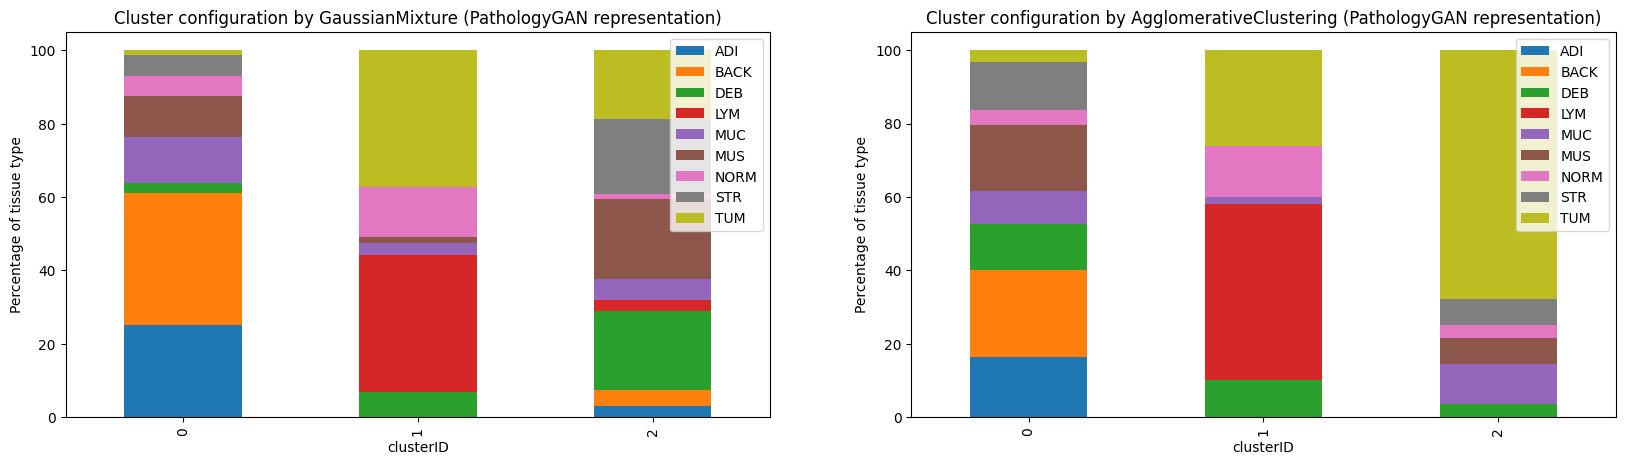

In [43]:
resulted_cluster_df = pd.DataFrame({'clusterID': gm_predict_pge, 'type': pge_test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


f, axes = plt.subplots(1, 2, figsize=(20,5))
number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[0] )

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('Cluster configuration by GaussianMixture (PathologyGAN representation)')

resulted_cluster_df = pd.DataFrame({'clusterID': ac_predict_pge , 'type': pge_test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[1] )

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('Cluster configuration by AgglomerativeClustering (PathologyGAN representation)')
f.show()

C:\Users\Vaishnavi Kshirsagar\AppData\Local\Temp\ipykernel_28504\4046999762.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Vaishnavi Kshirsagar\AppData\Local\Temp\ipykernel_28504\4046999762.py:16: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\Vaishnavi Kshirsagar\AppData\Local\Temp\ipykernel_28504\4046999762.py:27: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be s

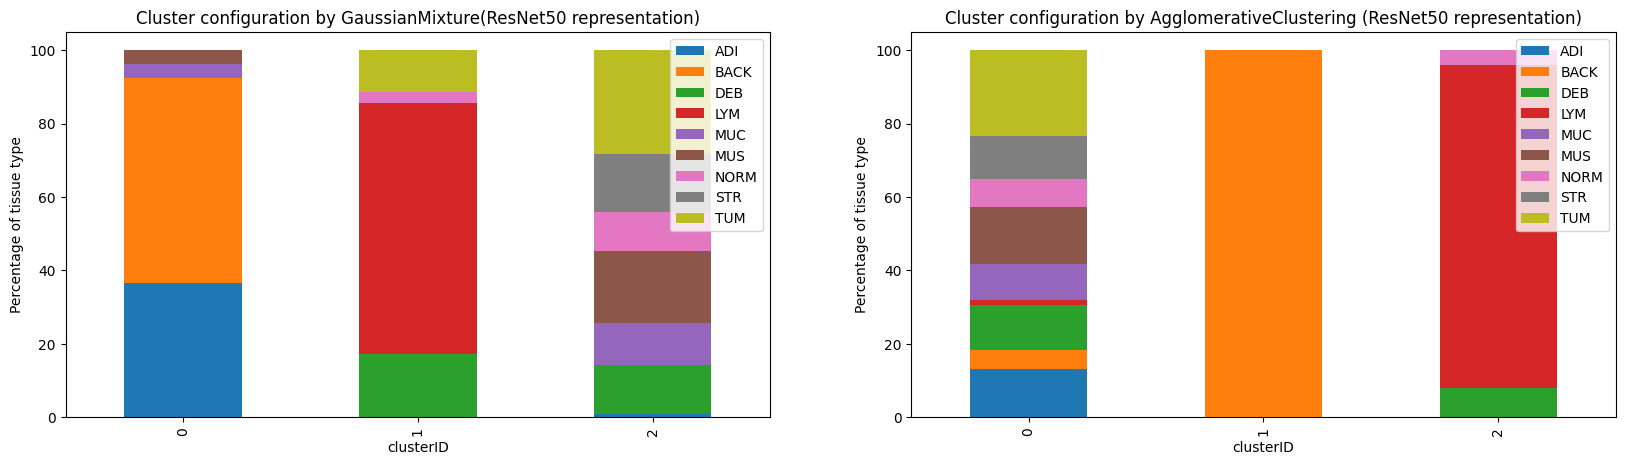

In [44]:
resulted_cluster_df = pd.DataFrame({'clusterID': gm_predict_rn, 'type': rn_test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


f, axes = plt.subplots(1, 2, figsize=(20,5))
number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[0] )

axes[0].set_ylabel('Percentage of tissue type')
axes[0].legend(loc='upper right')
axes[0].set_title('Cluster configuration by GaussianMixture(ResNet50 representation)')

resulted_cluster_df = pd.DataFrame({'clusterID': ac_predict_rn , 'type': rn_test_label})
label_proportion_df = resulted_cluster_df.groupby(['clusterID']).apply(lambda x: calculate_percent(x,'type')).rename(columns={'clusterID':'type_occurrence_percentage'}).reset_index()
pivoted_label_proportion_df = pd.pivot_table(label_proportion_df, index = 'clusterID', columns = 'type', values = 'type_occurrence_percentage')


number_of_tile_df = resulted_cluster_df.groupby('clusterID')['type'].count().reset_index().rename(columns={'type':'number_of_tile'})
df_idx = pivoted_label_proportion_df.index
(pivoted_label_proportion_df*100).loc[df_idx].plot.bar(stacked=True, ax = axes[1] )

axes[1].set_ylabel('Percentage of tissue type')
axes[1].legend(loc='upper right')
axes[1].set_title('Cluster configuration by AgglomerativeClustering (ResNet50 representation)')
f.show()